# PEM hydrogen NPV simulation

Run the Monte Carlo hydrogen model at 100,000 tH2/year. The notebook shows NPV, LPM, and LCOH distributions, NPV sign counts, and mean annual cost components. Greenfield European proton-exchange-membrane electrolysis for 2030, with purchased electricity specified at 200 bar.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hydrogen.hydrogen_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_hydrogen_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "pem"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_hydrogen_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_th2,lifetime_years,capex_eur_per_th2,fixed_opex_eur_per_th2,variable_opex_eur_per_th2,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_th2,present_value_total_cost_eur,lcoh_eur_per_th2,levelized_profit_margin_eur_per_th2
0,0,pem,absolute,not_applicable,"100,000.000",25,"9,771.346",300.422,31.454,none,...,"668,591,393.969",0.000,0.000,"701,779,030.040","48,220,969.960","-462,386,581.922","1,067,477.619","8,468,468,723.364","7,933.158",-433.158
1,1,pem,absolute,not_applicable,"100,000.000",25,"11,824.711",368.059,28.874,none,...,"743,182,207.263",0.000,0.000,"782,875,563.740","-32,875,563.740","-1,533,410,358.182","1,067,477.619","9,539,492,499.624","8,936.480","-1,436.480"
2,2,pem,absolute,not_applicable,"100,000.000",25,"9,520.012",295.514,32.110,none,...,"620,692,720.690",0.000,0.000,"653,455,125.230","96,544,874.770","78,593,747.970","1,067,477.619","7,927,488,393.472","7,426.374",73.626
3,3,pem,absolute,not_applicable,"100,000.000",25,"11,946.345",438.025,44.864,none,...,"785,408,351.957",0.000,0.000,"833,697,232.837","-83,697,232.837","-2,088,083,762.510","1,067,477.619","10,094,165,903.952","9,456.091","-1,956.091"
4,4,pem,absolute,not_applicable,"100,000.000",25,"8,029.008",336.045,45.422,none,...,"393,925,004.740",0.000,0.000,"432,071,761.410","317,928,238.590","2,590,911,948.819","1,067,477.619","5,415,170,192.623","5,072.865","2,427.135"


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoh_eur_per_th2 = results["lcoh_eur_per_th2"]
levelized_profit_margin_eur_per_th2 = results["levelized_profit_margin_eur_per_th2"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_profit_margin_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LPM EUR/tH2"),
    lcoh_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOH EUR/tH2"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LPM EUR/tH2,LCOH EUR/tH2
count,"100,000.000","100,000.000","100,000.000"
mean,122.452,114.711,"7,385.289"
std,"1,351.208","1,265.795","1,265.795"
min,"-3,236.097","-3,031.536","4,318.751"
5%,"-2,087.017","-1,955.092","5,322.412"
50%,118.788,111.279,"7,388.721"
95%,"2,324.527","2,177.588","9,455.092"
max,"3,395.913","3,181.249","10,531.536"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),52958,0.530
1,Negative (NPV < 0),47042,0.470


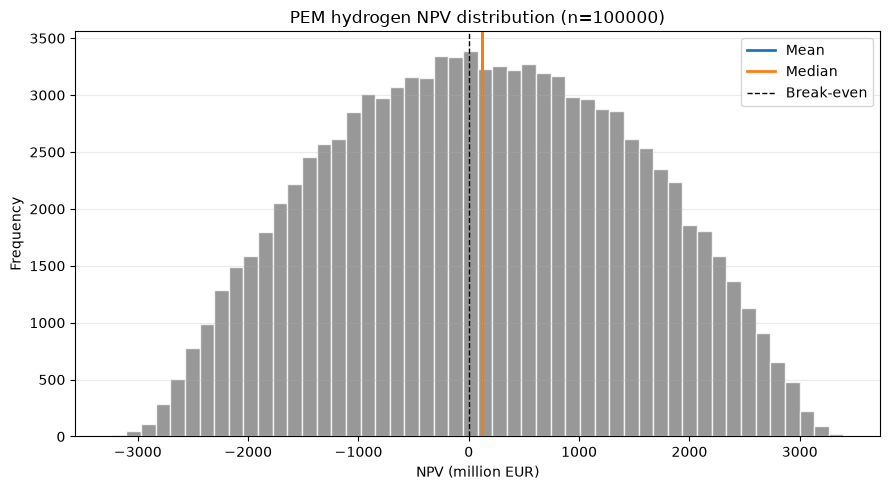

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"PEM hydrogen NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

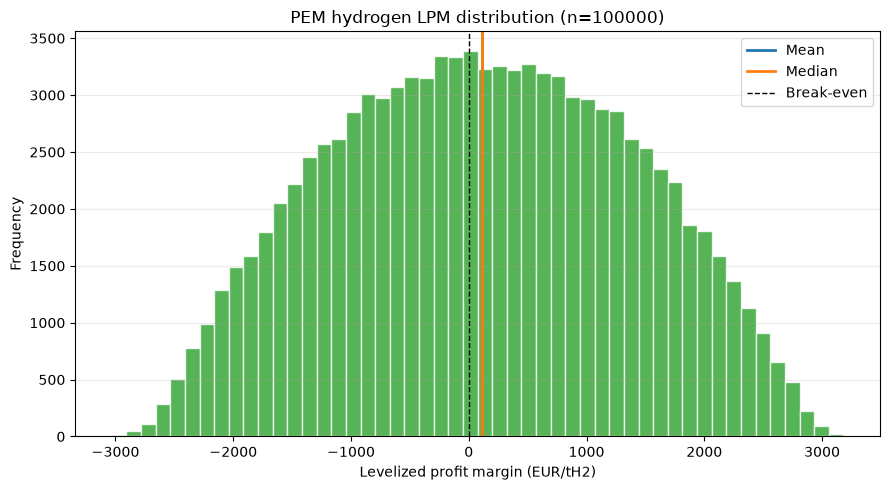

In [5]:
plot_financial_metric_distribution(
    levelized_profit_margin_eur_per_th2,
    title=f"PEM hydrogen LPM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized profit margin (EUR/tH2)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

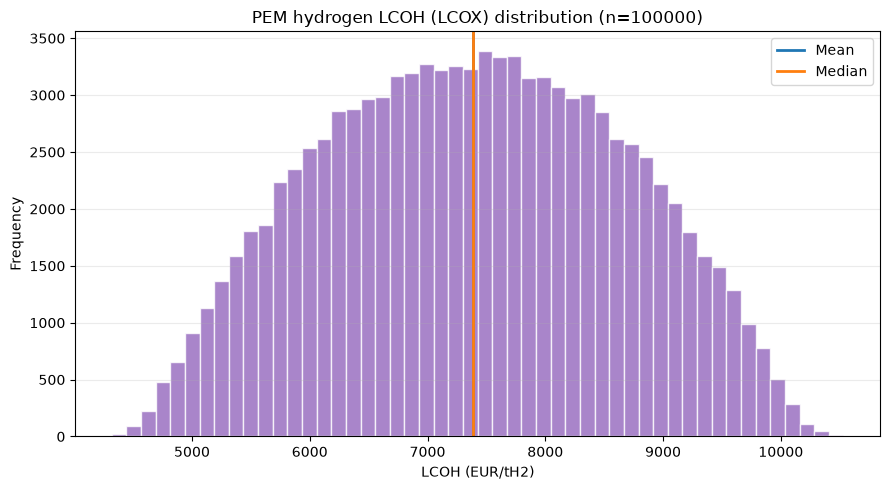

In [6]:
plot_financial_metric_distribution(
    lcoh_eur_per_th2,
    title=f"PEM hydrogen LCOH (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOH (EUR/tH2)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_biomethane_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      750.000
annual_fixed_opex_eur                    38.813
annual_variable_opex_eur                  3.834
annual_natural_gas_cost_eur               0.000
annual_biomethane_cost_eur                0.000
annual_biomass_cost_eur                   0.000
annual_fuel_cost_eur                      0.000
annual_electricity_cost_eur             593.208
annual_transport_and_storage_cost_eur     0.000
annual_emissions_cost_eur                 0.000
annual_net_cash_flow_eur                114.145
Name: Mean annual value, million EUR, dtype: float64